In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
x = pd.read_csv("/content/car_msrp_cleaned_dataset.csv")

In [ ]:
print(x.isnull().sum())

Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64


In [ ]:
x.duplicated().sum()

np.int64(9)

In [ ]:
x.drop_duplicates(inplace=True)

In [ ]:
x.value_counts().sum()

np.int64(9029)

In [ ]:
print(len(x), x.value_counts().sum())
print(x.isnull().sum())

9029 9029
Make                 0
Model                0
Year                 0
Engine Fuel Type     0
Engine HP            0
Engine Cylinders     0
Transmission Type    0
Driven_Wheels        0
Number of Doors      0
Vehicle Size         0
Vehicle Style        0
highway MPG          0
city mpg             0
Popularity           0
MSRP                 0
dtype: int64


In [ ]:
x[['MSRP', 'Engine HP', 'highway MPG', 'city mpg']].describe()

,MSRP,Engine HP,highway MPG,city mpg
count,9029.000000,9029.000000,9029.000000,9029.000000
mean,29289.762488,230.372162,26.545631,19.358622
std,15655.695082,77.739034,5.667537,4.346159
min,2000.000000,66.000000,12.500000,10.000000
25%,20445.000000,170.000000,23.000000,16.000000
50%,29050.000000,220.000000,26.000000,19.000000
75%,39095.000000,285.000000,30.000000,22.000000
max,67188.625000,461.250000,40.500000,31.000000


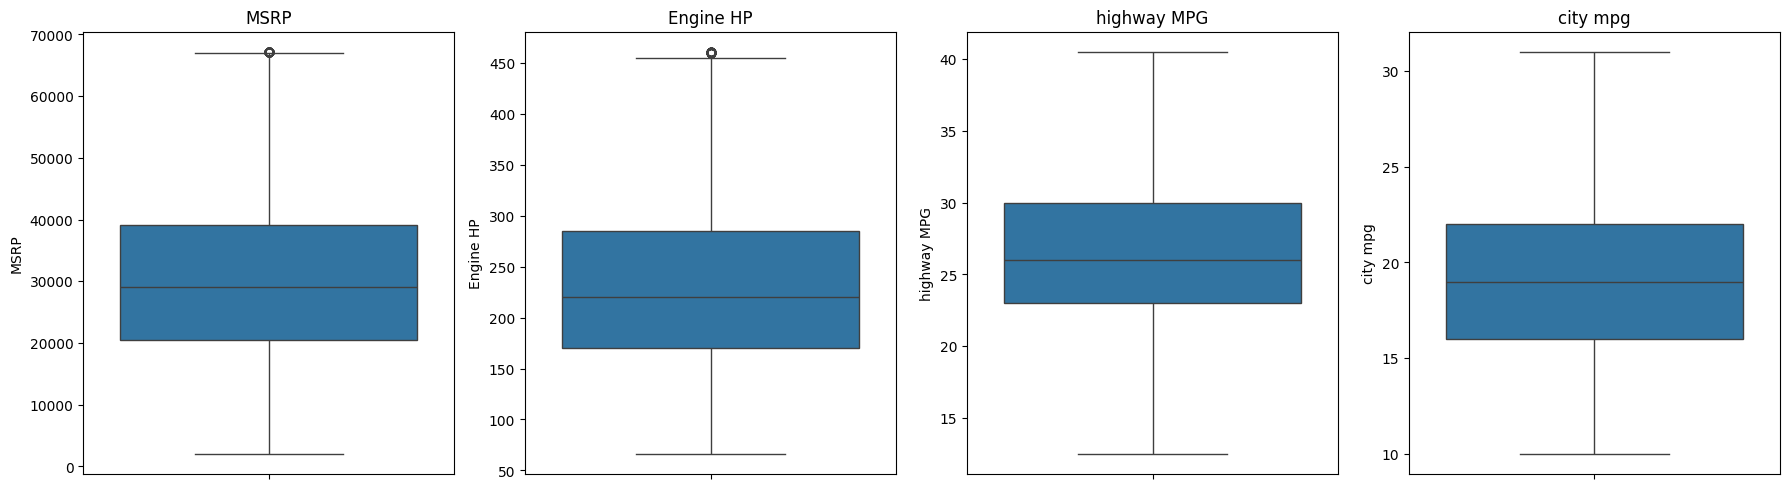

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols = ['MSRP', 'Engine HP', 'highway MPG', 'city mpg']
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for i, col in enumerate(cols):
    sns.boxplot(y=x[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
for col in cols:
    Q1 = x[col].quantile(0.25)
    Q3 = x[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = x[(x[col] < lower) | (x[col] > upper)]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(x)*100:.2f}%)")

MSRP: 84 outliers (0.93%)
Engine HP: 44 outliers (0.49%)
highway MPG: 0 outliers (0.00%)
city mpg: 0 outliers (0.00%)


In [ ]:
x[x['MSRP'] > x['MSRP'].quantile(0.75) + 1.5*(x['MSRP'].quantile(0.75)-x['MSRP'].quantile(0.25))][['Make','Model','MSRP']].sort_values('MSRP', ascending=False).head(10)

,Make,Model,MSRP
424,Alfa Romeo,4C,67188.625
455,BMW,5 Series Gran Turismo,67188.625
457,BMW,5 Series Gran Turismo,67188.625
462,BMW,5 Series,67188.625
475,BMW,5 Series,67188.625
885,Audi,A6,67188.625
890,Audi,A7,67188.625
891,Audi,A7,67188.625
893,Audi,A7,67188.625
894,Audi,A7,67188.625


In [ ]:
x['MSRP'].value_counts().head(10)

,count
MSRP,
2000.000,687
67188.625,84
29995.000,17
20995.000,15
21995.000,14
25995.000,14
24995.000,13
30995.000,13
23995.000,12


In [ ]:
x[x['MSRP'] == 67188.625].shape[0]

84

In [ ]:
x[x['MSRP'] == 2000][['Make','Model','Year','Engine HP']].head(10)
x[x['MSRP'] == 67188.625][['Make','Model','Year','Engine HP']].head(10)

,Make,Model,Year,Engine HP
424,Alfa Romeo,4C,2015,237.0
455,BMW,5 Series Gran Turismo,2015,445.0
457,BMW,5 Series Gran Turismo,2015,445.0
462,BMW,5 Series,2015,443.0
475,BMW,5 Series,2016,443.0
885,Audi,A6,2017,340.0
890,Audi,A7,2015,310.0
891,Audi,A7,2015,240.0
893,Audi,A7,2016,240.0
894,Audi,A7,2016,333.0


In [ ]:
print(x[x['MSRP'] == 2000][['Make','Model','Year','Engine HP']].head(10))

    Make Model  Year  Engine HP
16  Audi   100  1992      172.0
17  Audi   100  1992      172.0
18  Audi   100  1992      172.0
19  Audi   100  1993      172.0
20  Audi   100  1993      172.0
21  Audi   100  1993      172.0
22  Audi   100  1994      172.0
23  Audi   100  1994      172.0
24  Audi   100  1994      172.0
25  Audi   100  1994      172.0


In [ ]:
x[x['MSRP'] == 2000][['Make','Model','Year','Engine HP']].head(10)

,Make,Model,Year,Engine HP
16,Audi,100,1992,172.0
17,Audi,100,1992,172.0
18,Audi,100,1992,172.0
19,Audi,100,1993,172.0
20,Audi,100,1993,172.0
21,Audi,100,1993,172.0
22,Audi,100,1994,172.0
23,Audi,100,1994,172.0
24,Audi,100,1994,172.0
25,Audi,100,1994,172.0


In [ ]:
x['MSRP'] = x['MSRP'].replace(2000, np.nan)

In [ ]:
x['MSRP'] = x['MSRP'].replace(2000, np.nan)
x = x.dropna(subset=['MSRP'])  # or impute — but for target variable, dropping is safer

In [ ]:
print(x.duplicated().sum())
x = x.drop_duplicates()

0


In [ ]:
x['Model'].nunique()

611

In [ ]:
x[['Engine HP','Engine Cylinders','highway MPG','city mpg']].corr()

,Engine HP,Engine Cylinders,highway MPG,city mpg
Engine HP,1.000000,0.741536,-0.479573,-0.574740
Engine Cylinders,0.741536,1.000000,-0.707264,-0.753575
highway MPG,-0.479573,-0.707264,1.000000,0.939619
city mpg,-0.574740,-0.753575,0.939619,1.000000


In [ ]:
import numpy as np
x['MSRP'].skew()

np.float64(0.22678403484254053)

In [ ]:
import pandas as pd
import numpy as np

# Re-load the data and re-apply cleaning steps to ensure 'Model' column is present
x = pd.read_csv("/content/car_msrp_cleaned_dataset.csv")
x.drop_duplicates(inplace=True)
x['MSRP'] = x['MSRP'].replace(2000, np.nan)
x = x.dropna(subset=['MSRP'])
x = x.drop_duplicates() # Redundant but included for completeness of historical steps

x['Model'] = x['Model'].astype(str)
# Option A: Drop it (Make + Vehicle Size + Vehicle Style already capture a lot)
# x = x.drop(columns=['Model'])

# Option B: Keep but reduce cardinality — group rare models into "Other"
model_counts = x['Model'].value_counts()
rare_models = model_counts[model_counts < 10].index
x['Model'] = x['Model'].replace(rare_models, 'Other')

In [ ]:
x['MSRP'] = x['MSRP'].replace(2000, np.nan)
x = x.dropna(subset=['MSRP'])

In [ ]:
def remove_outliers_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] >= lower) & (df[col] <= upper)]

In [ ]:
for col in ['MSRP', 'Engine HP']:
    before = x.shape[0]
    x = remove_outliers_iqr(x, col)
    after = x.shape[0]
    print(f"{col}: removed {before - after} rows")

MSRP: removed 27 rows
Engine HP: removed 0 rows


In [ ]:
Q1 = x['MSRP'].quantile(0.25)
Q3 = x['MSRP'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

x['MSRP'] = x['MSRP'].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
print(f"Final shape: {x.shape}")

Final shape: (8216, 15)


In [ ]:
Q1 = x['Engine HP'].quantile(0.25)
Q3 = x['Engine HP'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

x['Engine HP'] = x['Engine HP'].clip(lower=lower_bound, upper=upper_bound)

In [ ]:
Q1 = x['Engine HP'].quantile(0.25)
Q3 = x['Engine HP'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers = x[(x['Engine HP'] < lower) | (x['Engine HP'] > upper)]
print(f"Engine HP: {len(outliers)} outliers remaining")

Engine HP: 0 outliers remaining


In [ ]:
x.isnull().sum()

,0
Make,0
Model,0
Year,0
Engine Fuel Type,0
Engine HP,0
Engine Cylinders,0
Transmission Type,0
Driven_Wheels,0
Number of Doors,0
Vehicle Size,0


In [ ]:
x['Model'].nunique()  # confirm still 611

303

In [ ]:
x.to_csv("final_dataset.csv")

In [ ]:
num_cols = x.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = x.select_dtypes(include=['object']).columns.tolist()


In [ ]:
print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['Year', 'Engine HP', 'Engine Cylinders', 'Number of Doors', 'highway MPG', 'city mpg', 'Popularity', 'MSRP']
Categorical columns: ['Make', 'Engine Fuel Type', 'Transmission Type', 'Driven_Wheels', 'Vehicle Size', 'Vehicle Style']


In [ ]:
print(x[num_cols].describe().T)


                   count          mean           std     min       25%  \
Year              8216.0   2011.647882      5.916340  1990.0   2008.00   
Engine HP         8216.0    235.441334     73.898476    79.0    175.00   
Engine Cylinders  8216.0      5.379990      1.381368     4.0      4.00   
Number of Doors   8216.0      3.555380      0.818740     2.0      4.00   
highway MPG       8216.0     26.685613      5.733745    13.0     23.00   
city mpg          8216.0     19.455818      4.393321    10.0     16.00   
Popularity        8216.0   1211.473771    847.066195    21.0    549.00   
MSRP              8216.0  30995.032680  13508.570025  2002.0  22373.75   

                      50%       75%       max  
Year               2015.0   2016.00   2017.00  
Engine HP           230.0    290.00    461.25  
Engine Cylinders      6.0      6.00      8.00  
Number of Doors       4.0      4.00      4.00  
highway MPG          26.0     31.00     40.50  
city mpg             19.0     22.00     31.00

In [ ]:
print("\nSkewness:")
for col in num_cols:
    print(f"{col}: {x[col].skew():.3f}")


Skewness:
Year: -1.246
Engine HP: 0.378
Engine Cylinders: 0.514
Number of Doors: -1.335
highway MPG: 0.271
city mpg: 0.537
Popularity: 0.800
MSRP: 0.107


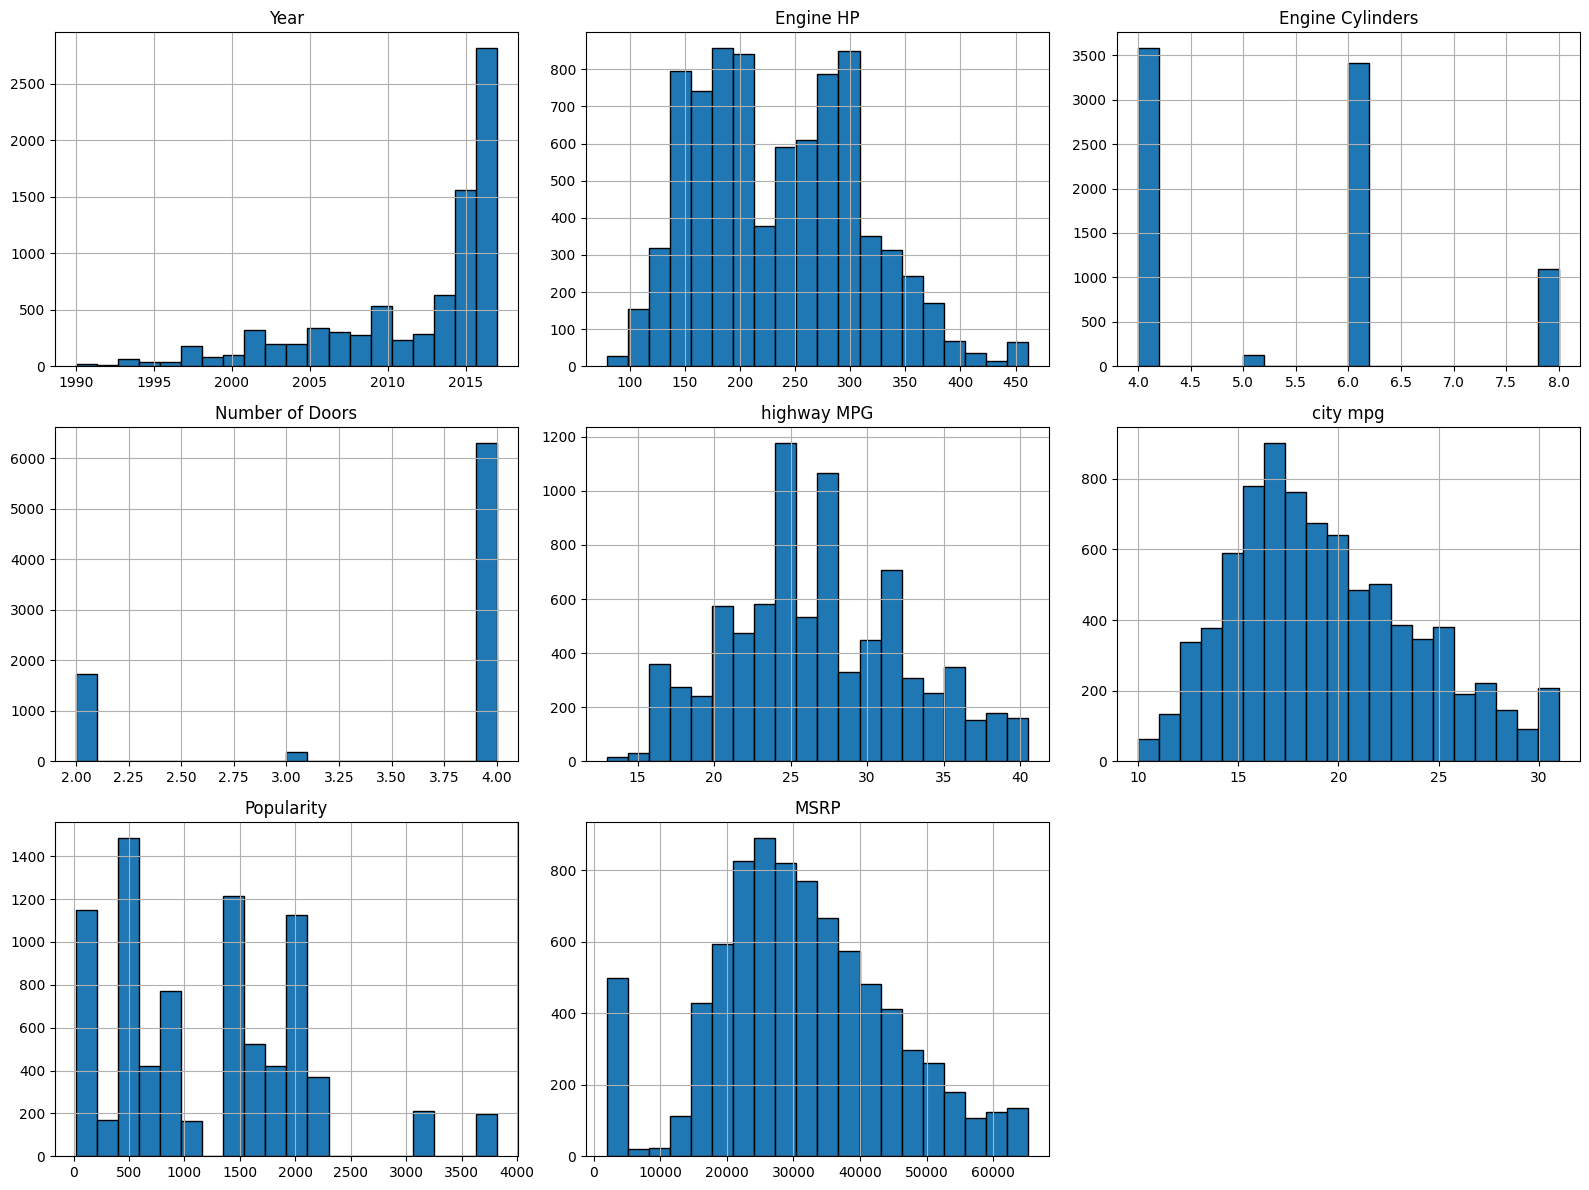

In [ ]:
#Histograms for numeric columns ----

x[num_cols].hist(figsize=(16, 12), bins=20, edgecolor='black')
plt.tight_layout()
plt.show()


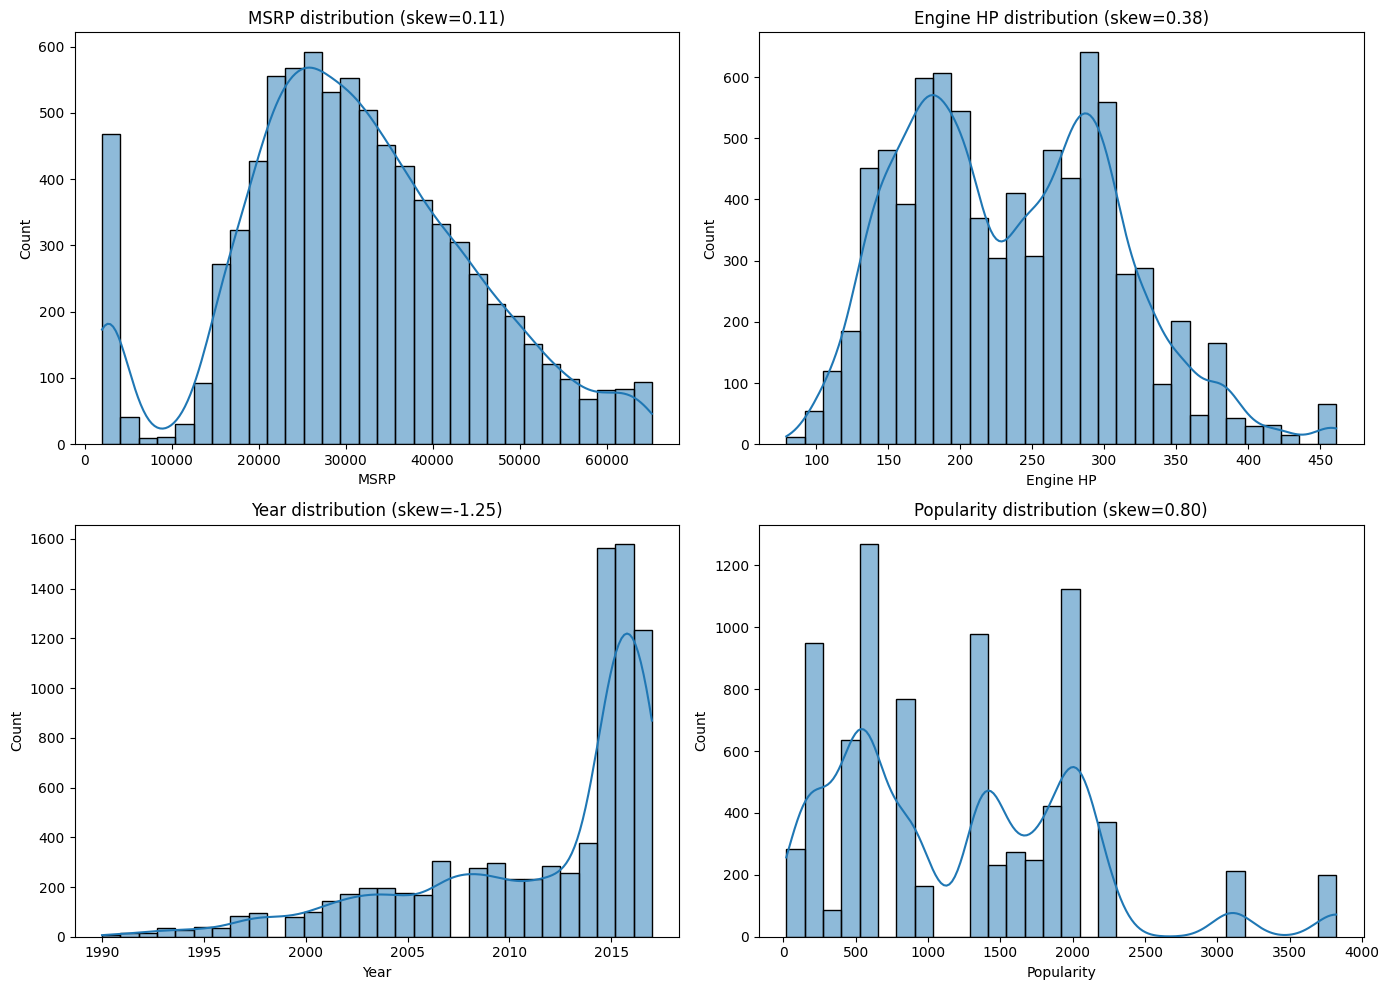

In [ ]:
key_cols = ['MSRP', 'Engine HP', 'Year', 'Popularity']  # adjust as needed
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(key_cols):
    sns.histplot(x[col], kde=True, ax=axes[i], bins=30)
    axes[i].set_title(f'{col} distribution (skew={[col].skew():.2f})')
plt.tight_layout()
plt.show()



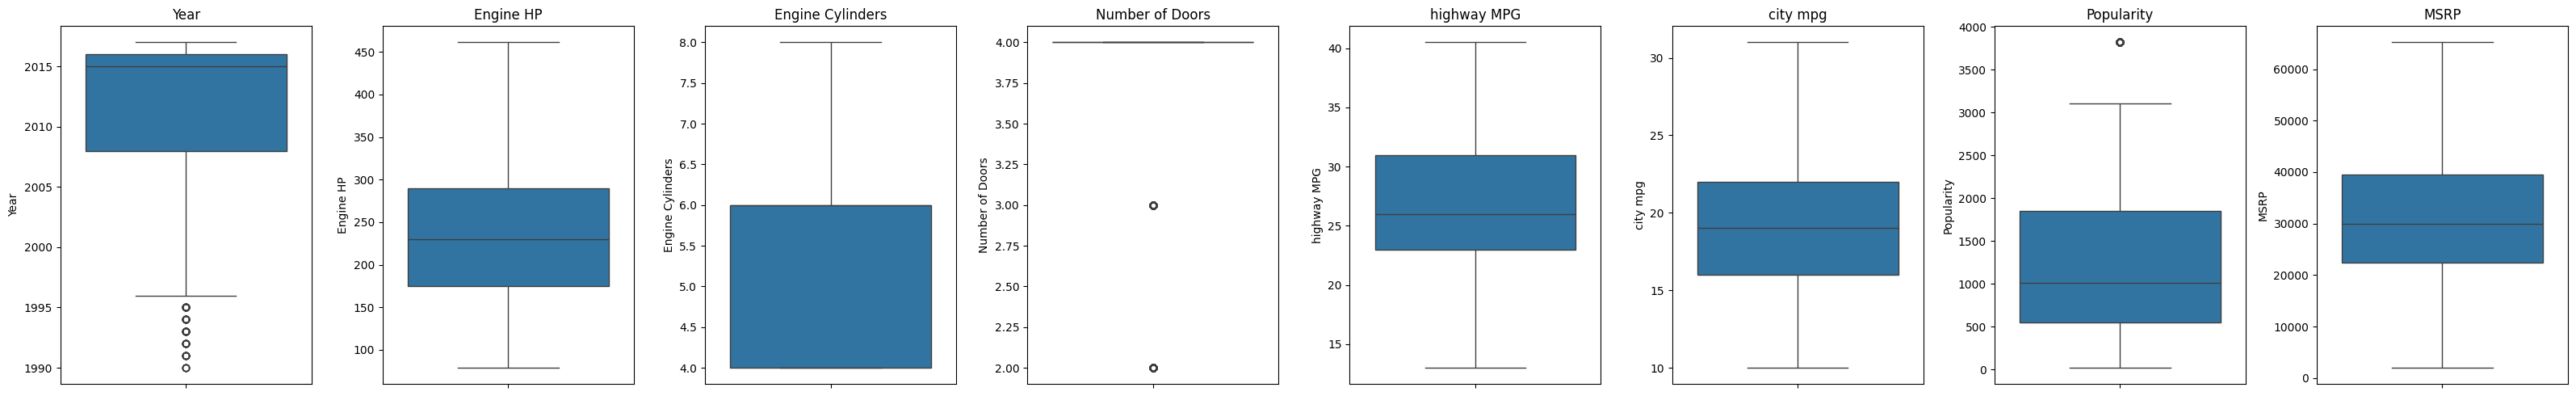

In [ ]:
# ---- 6. Boxplots for numeric columns (spread + outlier view) ----
fig, axes = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 5))
for i, col in enumerate(num_cols):
    sns.boxplot(y=x[col], ax=axes[i])
    axes[i].set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(x[col].value_counts())
    print(f"Unique values: {x[col].nunique()}")


--- Make ---
Make
Chevrolet        980
Toyota           620
Volkswagen       509
Nissan           504
GMC              451
Dodge            421
Mazda            383
Honda            370
Infiniti         314
Suzuki           313
Cadillac         273
Hyundai          233
Acura            232
Subaru           215
Kia              214
Audi             212
Volvo            201
BMW              198
Mercedes-Benz    195
Buick            170
Mitsubishi       167
Chrysler         165
Lexus            155
Pontiac          148
Lincoln          132
Saab              87
Land Rover        84
Oldsmobile        74
FIAT              59
Scion             55
Porsche           35
HUMMER            17
Plymouth          15
Lotus              9
Alfa Romeo         3
Genesis            3
Name: count, dtype: int64
Unique values: 36

--- Engine Fuel Type ---
Engine Fuel Type
regular unleaded                                5195
premium unleaded (recommended)                  1214
premium unleaded (required)     

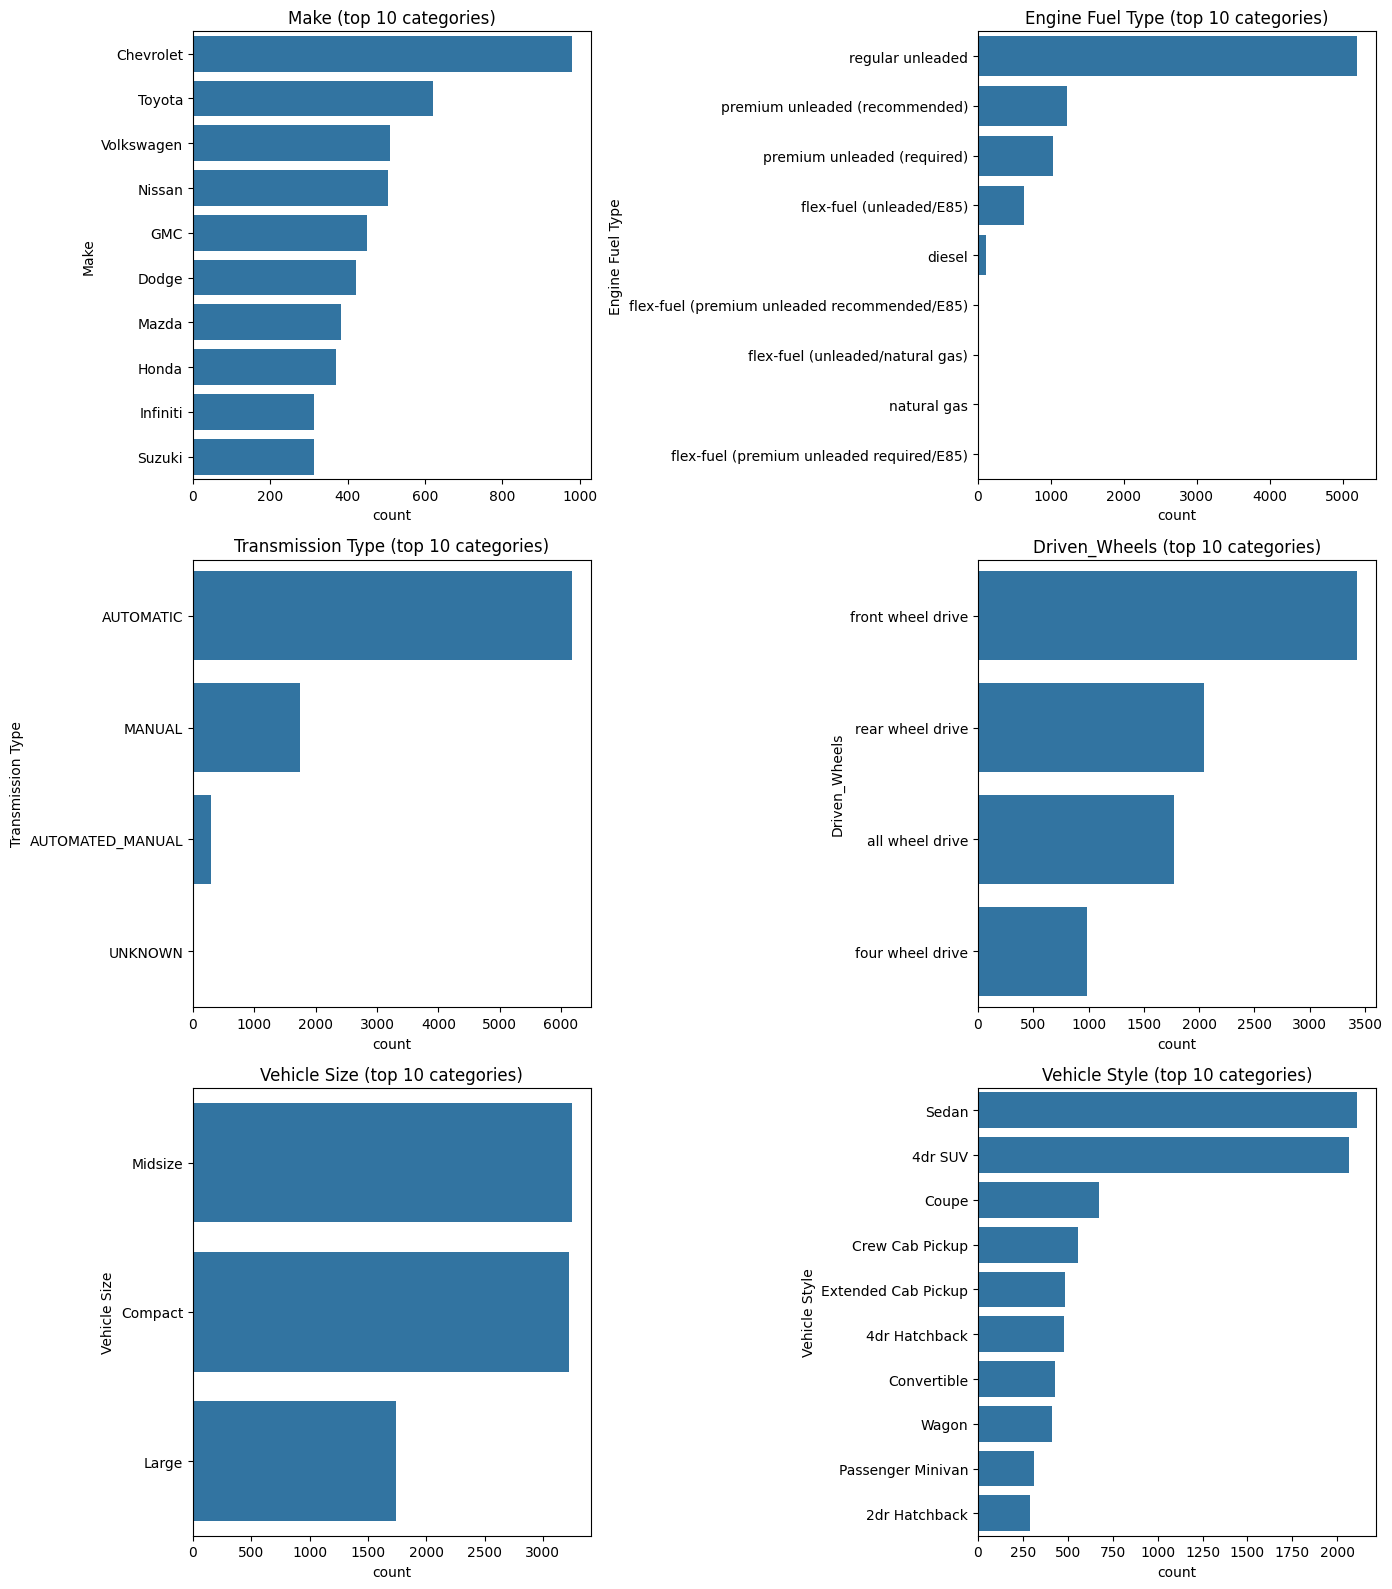

In [ ]:
# ---- 8. Bar plots for categorical columns ----
fig, axes = plt.subplots(3, 2, figsize=(14, 16))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    order = x[col].value_counts().index[:10]  # top 10 categories only
    sns.countplot(y=x[col], order=order, ax=axes[i])
    axes[i].set_title(f'{col} (top 10 categories)')
plt.tight_layout()
plt.show()